<a href="https://colab.research.google.com/github/NairMpc/DataScience/blob/main/Assignment_19_NLP_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Improving Customer Satisfaction through Automated Review Sentiment Analysis

## Introduction

Customer reviews are an important source of feedback for e-commerce companies, providing valuable insights into customer satisfaction and product performance. However, manually analyzing large volumes of reviews is challenging, and product ratings alone may not always accurately represent the sentiment expressed in review text. Therefore, automated sentiment analysis is essential for understanding customer opinions more effectively.

The objective of this assignment is to develop an automated sentiment analysis system that classifies Amazon product reviews as either **Positive** or **Negative**. The dataset consists of 10,000 pre-labeled customer reviews, making it suitable for supervised text classification using Natural Language Processing (NLP) and Machine Learning techniques.

In this assignment, the review text is preprocessed through cleaning operations such as lowercasing, punctuation removal, and stopword filtering. Exploratory Data Analysis (EDA) is then performed to examine sentiment distribution and identify frequently occurring words. The processed text is transformed into numerical features using NLP techniques and used to train classification models. Finally, the models are evaluated using appropriate performance metrics to assess their effectiveness in predicting customer sentiment.

The findings of this assignment demonstrate how NLP and Machine Learning can be applied to automate sentiment classification and support data-driven decision-making in e-commerce environments.


In [1]:
import pandas as pd
import re

In [2]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

The NLTK library was used for text preprocessing. The Punkt tokenizer and English stopword corpus were downloaded to support tokenization and stopword removal.

## Data Loading and Initial Inspection

The file extension .tsv stands for Tab-Separated Values.

In a TSV file, each column is separated by a tab character (\t) instead of a comma. When reading the file with Pandas, we must specify:

In [3]:
# Load the dataset
df = pd.read_csv('/content/amazonreviews.tsv', sep='\t')

# Display the first 5 rows of the DataFrame
print('First 5 rows of the dataset:')
display(df.head())

# Display basic information about the DataFrame
print('\nDataFrame Info:')
df.info()

# Display the shape of the DataFrame
print(f'\nShape of the DataFrame: {df.shape}')

First 5 rows of the dataset:


,label,review
0,pos,Stuning even for the non-gamer: This sound tra...
1,pos,The best soundtrack ever to anything.: I'm rea...
2,pos,Amazing!: This soundtrack is my favorite music...
3,pos,Excellent Soundtrack: I truly like this soundt...
4,pos,"Remember, Pull Your Jaw Off The Floor After He..."



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   10000 non-null  object
 1   review  10000 non-null  object
dtypes: object(2)
memory usage: 156.4+ KB

Shape of the DataFrame: (10000, 2)


The output shows the first 5 rows of the loaded dataset, confirming it has 'label' and 'review' columns.

 The df.info() output indicates that both columns have 10,000 non-null entries and are of object (string) type, meaning there are no missing values in these columns initially.

 df.shape tells the dataset contains 10,000 rows and 2 columns.

## Data Cleaning - Missing Values and Duplicates

In [4]:
# Check for missing values
print('Missing values in each column:')
display(df.isnull().sum())

# Check for duplicate rows
print('\nNumber of duplicate rows:')
duplicate_rows = df.duplicated().sum()
print(duplicate_rows)

if duplicate_rows > 0:
    print('\nDropping duplicate rows...')
    df.drop_duplicates(inplace=True)
    print(f'Shape after dropping duplicates: {df.shape}')
else:
    print('\nNo duplicate rows found.')

Missing values in each column:


,0
label,0
review,0



Number of duplicate rows:
0

No duplicate rows found.


### Text Preprocessing: Lowercasing, Punctuation Removal, and Stopwords Filtering

In [5]:
stop_words = set(stopwords.words('english'))
print(stop_words)

{'s', "they'd", "needn't", "shan't", "we'd", 'until', 'just', "you've", 'weren', "it's", 'doesn', 'wasn', 'any', 'll', 'hadn', "we've", 'your', "he'll", 'once', "don't", 'its', 'itself', 't', 'theirs', 'most', 'through', 'because', "wasn't", "they'll", 'myself', "wouldn't", "haven't", 'between', 'to', 'me', 'our', 'needn', 'very', "we'll", 'when', 'but', "you're", 'out', 'what', 'should', 'be', 'doing', 'if', 'at', 'do', "doesn't", 'his', 'same', 'were', 'it', 'a', "weren't", 'this', 'has', 'himself', 'y', 'did', "it'd", 'own', 'again', 've', 'only', 'wouldn', 'more', 'she', 'above', 'ourselves', 're', 'about', "we're", "hasn't", 'over', "he's", 'hers', 'down', 'up', "he'd", 'shan', 'don', 'and', 'for', 'are', 'after', 'an', 'my', "i'll", 'the', 'both', 'few', "it'll", 'too', 'them', 'by', 'some', 'under', 'each', 'as', "i'm", 'here', 'of', 'their', "you'll", 'being', "i've", "i'd", 'will', 'on', 'shouldn', 'have', 'her', 'other', 'further', 'yourselves', "they're", "aren't", "didn't",

### Text Preprocessing

The review text is cleaned through lowercasing, punctuation removal, tokenization, and stopword filtering. The processed text is stored in the `cleaned_review` column.

In [6]:
# Define a text preprocessing function
def preprocess_text(text):
    # Convert text to lowercase
    text = text.lower()
    # Remove punctuation and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Tokenize the text
    words = word_tokenize(text)
    # Remove stopwords
    words = [word for word in words if word not in stop_words]
    # Join the words back into a string
    return ' '.join(words)

# Apply the preprocessing function to the 'review' column
df['cleaned_review'] = df['review'].apply(preprocess_text)

# Display the first few original and cleaned reviews
print('Original vs. Cleaned Reviews:')
comparison_df = df[['review', 'cleaned_review']].head()
display(comparison_df)

Original vs. Cleaned Reviews:


,review,cleaned_review
0,Stuning even for the non-gamer: This sound tra...,stuning even nongamer sound track beautiful pa...
1,The best soundtrack ever to anything.: I'm rea...,best soundtrack ever anything im reading lot r...
2,Amazing!: This soundtrack is my favorite music...,amazing soundtrack favorite music time hands i...
3,Excellent Soundtrack: I truly like this soundt...,excellent soundtrack truly like soundtrack enj...
4,"Remember, Pull Your Jaw Off The Floor After He...",remember pull jaw floor hearing youve played g...


The preprocess_text() function is applied to every review in the review column using df['review'].apply(preprocess_text). The resulting cleaned text for each review is stored in a new column called cleaned_review. The cleaned_review column contains the preprocessed review text, consisting of lowercase meaningful words with stopwords, punctuation, numbers, and special characters removed. This cleaned text is more suitable for further NLP tasks such as sentiment analysis and text classification.

**The cleaned_review column contains the preprocessed review text, consisting of lowercase meaningful words with stopwords, punctuation, numbers, and special characters removed.**


In [7]:
df.head()

,label,review,cleaned_review
0,pos,Stuning even for the non-gamer: This sound tra...,stuning even nongamer sound track beautiful pa...
1,pos,The best soundtrack ever to anything.: I'm rea...,best soundtrack ever anything im reading lot r...
2,pos,Amazing!: This soundtrack is my favorite music...,amazing soundtrack favorite music time hands i...
3,pos,Excellent Soundtrack: I truly like this soundt...,excellent soundtrack truly like soundtrack enj...
4,pos,"Remember, Pull Your Jaw Off The Floor After He...",remember pull jaw floor hearing youve played g...


## Exploratory Analysis: Sentiment Distribution
After preprocessing the review text, the next step is to analyze the distribution of sentiment labels in the dataset. This helps understand how many reviews belong to each sentiment category and whether the dataset is balanced.

Sentiment Distribution:


,count
label,
neg,5097
pos,4903


/tmp/ipykernel_2336/1948798942.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='viridis')


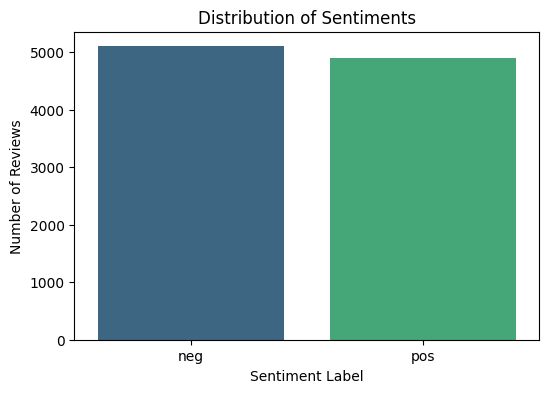

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Analyze sentiment distribution
sentiment_counts = df['label'].value_counts()

print('Sentiment Distribution:')
display(sentiment_counts)

# Plotting the sentiment distribution
plt.figure(figsize=(6, 4))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='viridis')
plt.title('Distribution of Sentiments')
plt.xlabel('Sentiment Label')
plt.ylabel('Number of Reviews')
plt.show()

 The value_counts() function counts the number of reviews in each sentiment category and returns the result as a Pandas Series, where the index contains the sentiment labels (neg, pos) and the values contain their corresponding counts.

Interpretation: The dataset contains 5,097 negative reviews and 4,903 positive reviews. Since the counts are nearly equal, the dataset is well-balanced, which is desirable for training and evaluating sentiment analysis models.

## Exploratory Analysis: Word Clouds
Word clouds are used to visualize the most frequently occurring words in positive and negative reviews. The cleaned reviews are first separated based on their sentiment labels (pos and neg). All reviews within each category are combined into a single text, and a word cloud is generated. In the visualization, words that appear more frequently are displayed in larger font sizes, helping identify prominent terms and patterns associated with each sentiment.

Positive and negative reviews were separated using the sentiment labels to generate independent word clouds for each class.

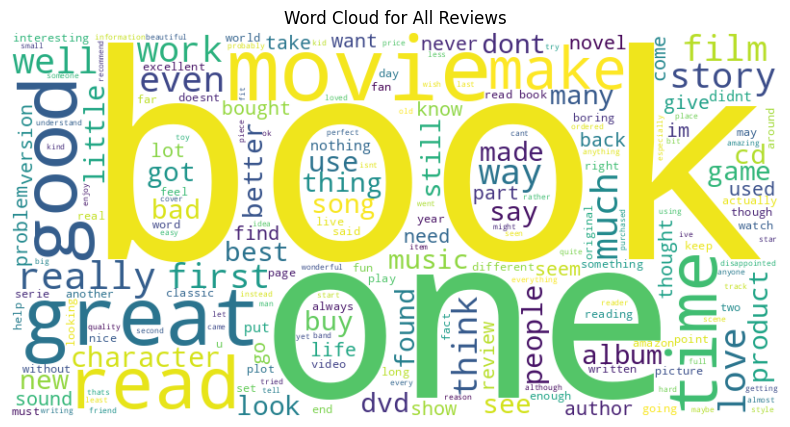

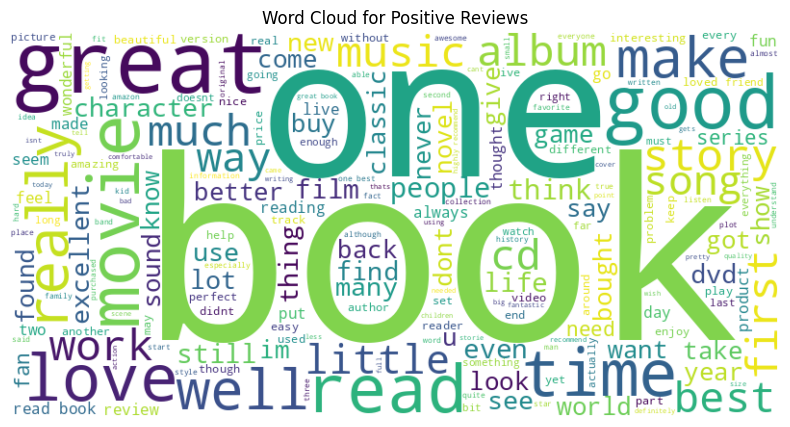

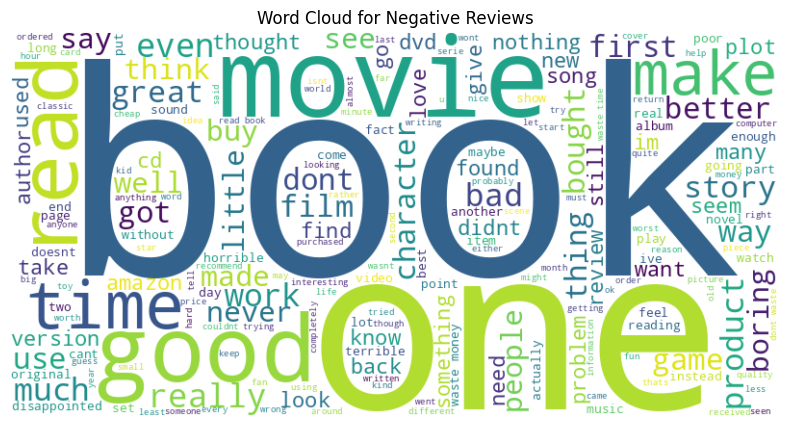

In [9]:
from wordcloud import WordCloud

all_reviews = ' '.join(df['cleaned_review'])

# Generate a word cloud for  cleaned reviews
wordcloud_all = WordCloud(width=800, height=400, background_color='white').generate(all_reviews)

# Display the generated image:
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_all, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for All Reviews')

# Separate positive and negative reviews
positive_reviews = ' '.join(df[df['label'] == 'pos']['cleaned_review'])
negative_reviews = ' '.join(df[df['label'] == 'neg']['cleaned_review'])

# Generate a word cloud for positive reviews
wordcloud_pos = WordCloud(width=800, height=400, background_color='white').generate(positive_reviews)

# Display the generated image:
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_pos, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for Positive Reviews')
plt.show()

# Generate a word cloud for negative reviews
wordcloud_neg = WordCloud(width=800, height=400, background_color='white').generate(negative_reviews)

# Display the generated image:
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for Negative Reviews')
plt.show()

**Interpretation:**

The word clouds provide a visual representation of the most frequently occurring words in positive reviews, negative reviews, and the complete review dataset. Larger words indicate higher frequency of occurrence. The positive and negative word clouds help identify the terms commonly used by satisfied and dissatisfied customers, while the overall word cloud highlights the main topics discussed across all reviews. Words such as book, read, good, and one appear prominently in all three word clouds because they are commonly used when discussing the products, irrespective of sentiment. This demonstrates that word clouds reveal word frequency and key themes but do not capture the context or sentiment associated with those words. Therefore, word clouds are valuable for exploratory text analysis, helping to identify frequently discussed topics and patterns in customer reviews before performing more detailed sentiment analysis.

## Exploratory Analysis: Most Common Positive and Negative Words
While word clouds provide a visual overview of frequently occurring words, they do not show the exact frequency of each word. The purpose of identifying the most common positive and negative words is to quantitatively analyze which words appear most often in each sentiment category and how frequently they occur. This helps uncover the key terms associated with positive and negative reviews and provides a more precise understanding of the language used by reviewers than a word cloud alone.

20 Most Common Positive Words:
- book: 3313
- great: 2087
- one: 1835
- good: 1635
- read: 1553
- like: 1268
- movie: 1085
- would: 943
- love: 902
- time: 871
- well: 854
- really: 827
- best: 801
- get: 793
- story: 713
- first: 708
- much: 650
- cd: 581
- music: 559
- also: 557


/tmp/ipykernel_2336/1531367368.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[word for word, count in common_positive_words], y=[count for word, count in common_positive_words], palette='viridis')


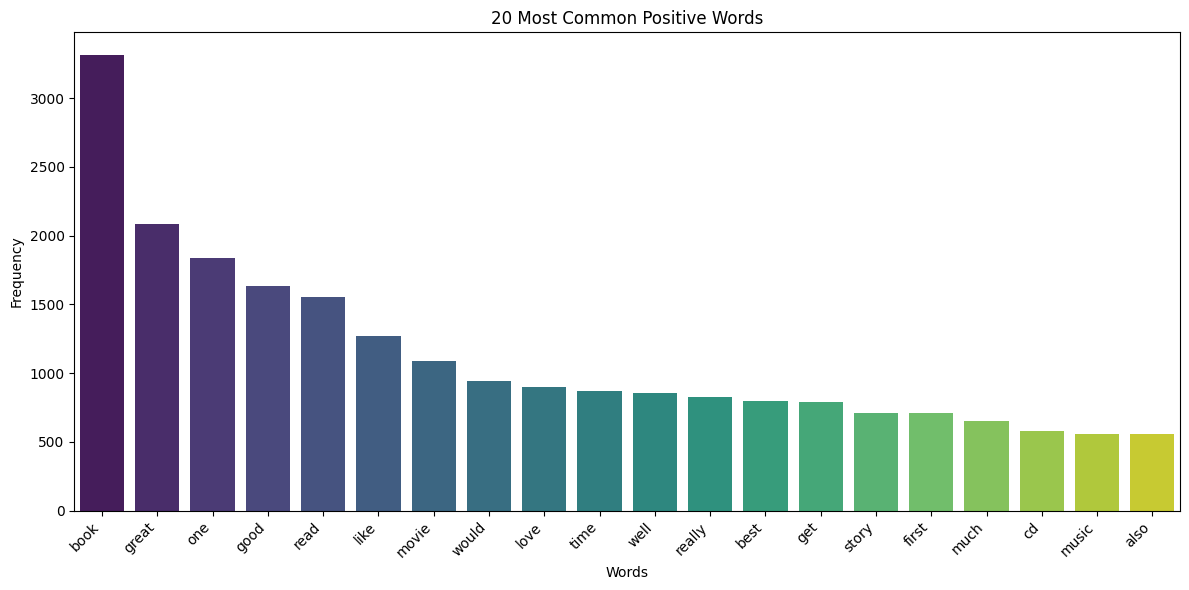

In [10]:
from collections import Counter

# Get all words from positive reviews
positive_words = ' '.join(df[df['label'] == 'pos']['cleaned_review']).split()
# Get all words from negative reviews
negative_words = ' '.join(df[df['label'] == 'neg']['cleaned_review']).split()

# Get the 20 most common positive words
common_positive_words = Counter(positive_words).most_common(20)
print('20 Most Common Positive Words:')
for word, count in common_positive_words:
    print(f'- {word}: {count}')

# Plotting the most common positive words
plt.figure(figsize=(12, 6))
sns.barplot(x=[word for word, count in common_positive_words], y=[count for word, count in common_positive_words], palette='viridis')
plt.title('20 Most Common Positive Words')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

The 20 most frequent words were identified separately for positive and negative reviews using the Counter() function. This helps reveal the terms most commonly associated with each sentiment category.


20 Most Common Negative Words:
- book: 3184
- one: 2022
- like: 1547
- movie: 1465
- would: 1438
- dont: 1240
- read: 1187
- get: 1139
- good: 1134
- time: 1034
- even: 898
- buy: 814
- really: 778
- much: 769
- bad: 749
- money: 744
- first: 736
- could: 658
- better: 656
- great: 632


/tmp/ipykernel_2336/2420536253.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[word for word, count in common_negative_words], y=[count for word, count in common_negative_words], palette='magma')


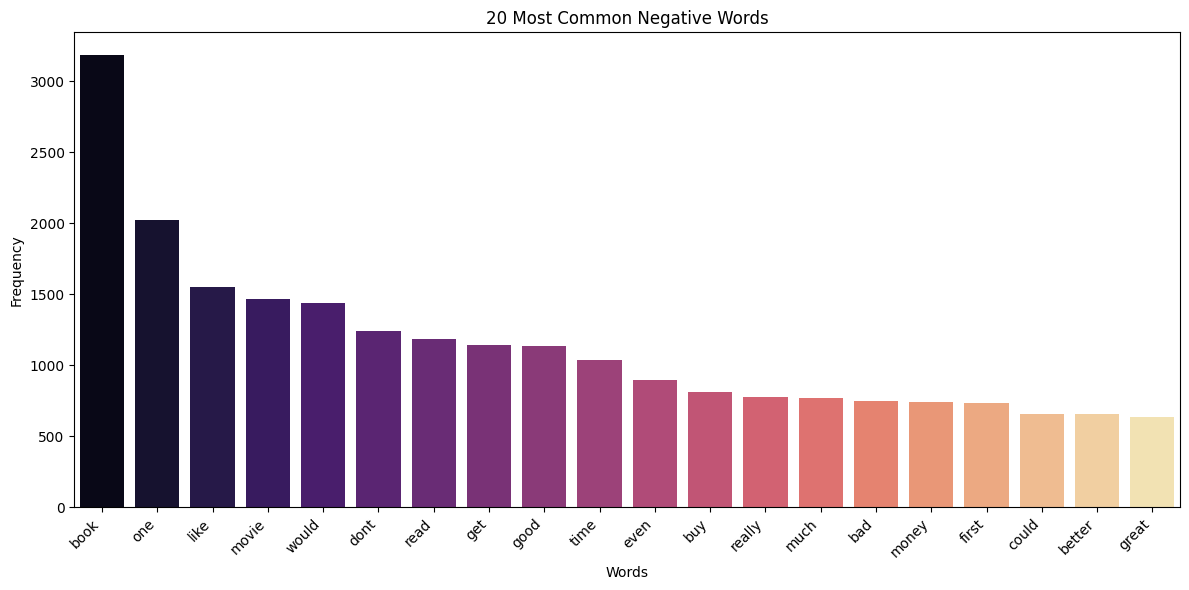

In [11]:
# Get the 20 most common negative words
common_negative_words = Counter(negative_words).most_common(20)
print('\n20 Most Common Negative Words:')
for word, count in common_negative_words:
    print(f'- {word}: {count}')

# Plotting the most common negative words
plt.figure(figsize=(12, 6))
sns.barplot(x=[word for word, count in common_negative_words], y=[count for word, count in common_negative_words], palette='magma')
plt.title('20 Most Common Negative Words')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Feature Extraction and Model Preparation

After completing data cleaning, text preprocessing, and exploratory analysis, the review text must be transformed into a numerical format suitable for machine learning algorithms. For this purpose, the **TF-IDF (Term Frequency–Inverse Document Frequency) Vectorizer** was used to convert the cleaned reviews into numerical feature vectors. TF-IDF assigns greater importance to informative words while reducing the influence of commonly occurring terms, thereby enhancing the representation of textual data.

The sentiment labels (**pos** and **neg**) were defined as the target variable. The dataset was then divided into training and testing sets using an 80:20 ratio with stratified sampling to maintain the original class distribution in both subsets. A **Logistic Regression** classifier was subsequently trained on the TF-IDF features to learn the relationship between review content and sentiment labels.

The resulting model can automatically classify unseen customer reviews as positive or negative, enabling efficient sentiment monitoring and supporting data-driven decision-making for improving customer satisfaction.



In [12]:
# Feature Extraction: TF-IDF
# Convert text reviews into numerical feature vectors using TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(max_features=5000) # Limiting to 5000 features to manage dimensionality
X = tfidf_vectorizer.fit_transform(df['cleaned_review'])
y = df['label'] # Target variable

print(f'Shape of TF-IDF feature matrix: {X.shape}')

# Split the dataset into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'y_test shape: {y_test.shape}')

# Model Training: Logistic Regression
from sklearn.linear_model import LogisticRegression

# Initialize and train the Logistic Regression model
log_reg_model = LogisticRegression(solver='liblinear', random_state=42)
log_reg_model.fit(X_train, y_train)

print('\nLogistic Regression model trained successfully.')

Shape of TF-IDF feature matrix: (10000, 5000)
X_train shape: (8000, 5000)
X_test shape: (2000, 5000)
y_train shape: (8000,)
y_test shape: (2000,)

Logistic Regression model trained successfully.


The TF-IDF matrix contains one row for each review and one column for each selected vocabulary term. Each value represents the importance of a word within a review.

**Why was the target variable not encoded?**

The target variable contains two categorical labels, pos and neg. Scikit-learn's Logistic Regression can directly handle string class labels, so explicit label encoding is not required. Keeping the original labels also makes the model output easier to interpret.

## Cross-Validation

Cross-validation is a model validation technique used to assess how well a machine learning model is likely to perform on unseen data. In this assignment, 5-fold cross-validation is used, where the training dataset is divided into five equal subsets (folds). The model is trained on four folds and validated on the remaining fold. This process is repeated five times, with each fold serving as the validation set once. The performance scores obtained from all five runs are then averaged.

The purpose of cross-validation is to evaluate the robustness and generalization capability of the Logistic Regression model. Rather than relying on a single train-test split, cross-validation provides a more reliable estimate of model performance by testing it on multiple subsets of the data. Consistent cross-validation scores indicate that the model performs reliably and is not significantly overfitting the training data.

In [13]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Initialize Stratified K-Fold cross-validation
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Perform 5-fold cross-validation
cv_scores = cross_val_score(log_reg_model, X, y, cv=kf, scoring='accuracy')

print('Cross-validation scores:', cv_scores)
print('Mean cross-validation score: {:.4f}'.format(cv_scores.mean()))

Cross-validation scores: [0.848 0.855 0.859 0.854 0.857]
Mean cross-validation score: 0.8546


The 5-fold cross-validation scores ranged from 84.8% to 85.9%, with a mean accuracy of 85.46%. The small variation among the fold scores indicates that the model produces consistent results across different subsets of the dataset, demonstrating good stability and robustness. In addition, stratified sampling was used during the train-test split to preserve the original class distribution in both training and testing datasets, ensuring a fair and reliable evaluation. These results suggest that the model generalizes well to unseen data, is not significantly overfitting, and is likely to perform reliably on new customer reviews.


## Model Evaluation

After training the Logistic Regression model, it is crucial to evaluate its performance on unseen data to assess its generalization capabilities. This section will involve:

1.  **Making Predictions:** Using the trained model to predict sentiment labels on the test dataset.
2.  **Calculating Evaluation Metrics:** Quantifying the model's performance using metrics such as accuracy, precision, recall, and F1-score.
3.  **Generating a Confusion Matrix:** Visualizing the classification results to understand where the model is performing well and where it is making errors (e.g., misclassifying positive reviews as negative or vice versa).

In [14]:
# Make predictions on the test set
y_pred = log_reg_model.predict(X_test)

# Evaluate the model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label='pos')
recall = recall_score(y_test, y_pred, pos_label='pos')
f1 = f1_score(y_test, y_pred, pos_label='pos')

print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1-Score: {f1:.4f}')

print('\nClassification Report:')
print(classification_report(y_test, y_pred))

Accuracy: 0.8525
Precision: 0.8500
Recall: 0.8491
F1-Score: 0.8496

Classification Report:
              precision    recall  f1-score   support

         neg       0.85      0.86      0.86      1019
         pos       0.85      0.85      0.85       981

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000



The trained Logistic Regression model was evaluated on the test dataset using Accuracy, Precision, Recall, and F1-Score. Since the target variable contains text labels ('pos' and 'neg'), pos_label='pos' was specified for Precision, Recall, and F1-Score to indicate that positive reviews should be treated as the positive class during metric calculation. This parameter is not required for Accuracy because Accuracy measures the overall proportion of correct predictions and does not depend on a specific positive class.

The model achieved an Accuracy of 85.25%, indicating that approximately 85 out of every 100 reviews were classified correctly. The Precision of 85.00% shows that when the model predicted a review as positive, it was correct 85% of the time. The Recall of 84.91% indicates that the model successfully identified about 85% of all actual positive reviews. The F1-Score of 84.96% demonstrates a good balance between Precision and Recall.

The classification report provides performance metrics for both sentiment classes. For the negative class, the model achieved Precision, Recall, and F1-Score values of approximately 0.85–0.86, while for the positive class, all three metrics were approximately 0.85. The support values show that the test dataset contained 1,019 negative reviews and 981 positive reviews, indicating a well-balanced test set.

The macro average and weighted average values are both approximately 0.85, indicating consistent performance across both classes. Overall, the results suggest that the Logistic Regression model performs well and is able to distinguish positive and negative reviews with good accuracy and balanced classification performance.

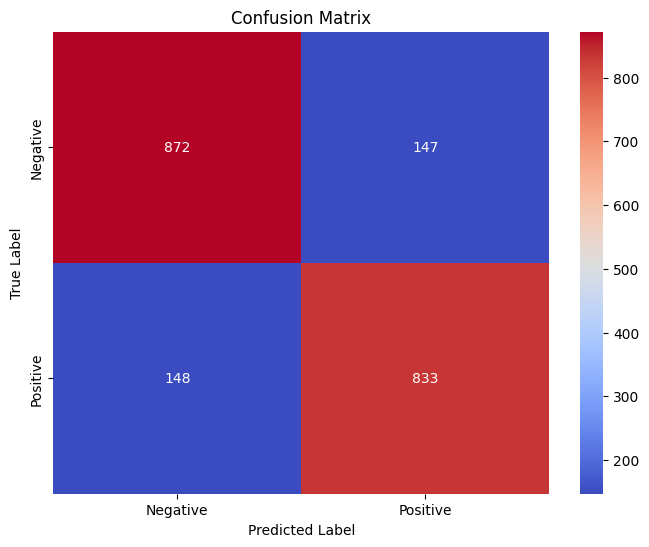

In [15]:
# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=['neg', 'pos'])

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

A confusion matrix was generated to evaluate the model's classification performance. It compares the actual and predicted sentiment classes and provides a detailed view of correct and incorrect classifications.

From the confusion matrix, 872 negative reviews and 833 positive reviews were correctly classified. However, 147 negative reviews were incorrectly classified as positive, and 148 positive reviews were incorrectly classified as negative. Overall, the model correctly classified 1,705 out of 2,000 reviews, corresponding to an accuracy of approximately 85.25%.

Meaningful class names were provided for the axes to improve the readability of the confusion matrix.

### ROC-AUC Score
ROC-AUC (Receiver Operating Characteristic – Area Under the Curve) measures the model's ability to distinguish between positive and negative reviews across different classification thresholds. A higher ROC-AUC value indicates better class separation and stronger predictive performance. Unlike accuracy, ROC-AUC evaluates the ranking capability of the classifier and is less sensitive to the chosen decision threshold.

In [16]:
from sklearn.metrics import roc_auc_score

y_prob = log_reg_model.predict_proba(X_test)[:,1]

y_test_binary = y_test.map({'neg':0,'pos':1})

roc_auc = roc_auc_score(y_test_binary, y_prob)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.9249309000549197


A ROC-AUC score close to 1 indicates excellent discrimination between positive and negative reviews, while a score of 0.5 indicates random guessing.

### Save the Model and Vectorizer

In [17]:
import pickle

with open('logistic_regression_model.pkl', 'wb') as file:
    pickle.dump(log_reg_model, file)

with open('tfidf_vectorizer.pkl', 'wb') as file:
    pickle.dump(tfidf_vectorizer, file)

print("Model and vectorizer saved successfully.")

Model and vectorizer saved successfully.


## Making Predictions on New Data

Once the model is trained and evaluated, its primary purpose is to predict the sentiment of new, unseen reviews. This involves applying the same preprocessing steps to new text as were applied to the training data, transforming it using the trained TF-IDF vectorizer, and then passing the numerical features to the Logistic Regression model for prediction.

In [20]:
# Example new reviews
new_reviews = [
    "This product is absolutely fantastic! I love it.",
    "Terrible quality, completely broken after one use. Very disappointed.",
    "It's okay, nothing special, but it gets the job done.",
    "This produt catched fire while installing",
    "Dosa made was tastefull, Iddily was worse"
]

# Preprocess the new reviews using the same function
cleaned_new_reviews = [preprocess_text(review) for review in new_reviews]

# Transform the cleaned new reviews using the *trained* TF-IDF vectorizer
X_new = tfidf_vectorizer.transform(cleaned_new_reviews)

# Make predictions
new_predictions = log_reg_model.predict(X_new)

print('Sentiment predictions for new reviews:')
for review, sentiment in zip(new_reviews, new_predictions):
    print(f'Review: "{review}" -> Predicted Sentiment: {sentiment}')

Sentiment predictions for new reviews:
Review: "This product is absolutely fantastic! I love it." -> Predicted Sentiment: pos
Review: "Terrible quality, completely broken after one use. Very disappointed." -> Predicted Sentiment: neg
Review: "It's okay, nothing special, but it gets the job done." -> Predicted Sentiment: neg
Review: "This produt catched fire while installing" -> Predicted Sentiment: neg
Review: "Dosa made was tastefull, Iddily was worse" -> Predicted Sentiment: neg


## Conclusion

The objective of this assignment was to develop an automated sentiment analysis system capable of classifying Amazon customer reviews as positive or negative. After performing data cleaning, text preprocessing, and exploratory analysis, the review text was transformed into numerical features using TF-IDF and used to train a Logistic Regression classifier.

The model achieved a mean cross-validation accuracy of 85.46% and a test accuracy of 85.25%, indicating consistent and reliable performance. The Precision, Recall, and F1-Score values were also approximately 85%, demonstrating balanced classification performance across both sentiment classes. The confusion matrix further confirmed that the model was able to correctly classify the majority of reviews.

Overall, the results show that the proposed sentiment analysis system can effectively identify positive and negative customer feedback. Such a system can help e-commerce companies monitor customer satisfaction, detect products receiving increased negative feedback, and support faster decision-making to improve product quality and customer experience.

##Future Improvements
Experiment with Support Vector Machines (SVM).

Use Word2Vec embeddings.

Use transformer models such as BERT.

Deploy the model as a real-time sentiment analysis API.